<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/FINAL_SET1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device: cuda

================ STEP 1: DATA LOADING ================
📊 Dataset Sizes
Train: (160000, 2)
Test : (160000, 2)
PHI  : (235795, 2)

📊 Train Class Distribution
labels
1    0.5
0    0.5
Name: proportion, dtype: float64

================ STEP 2: LEXICAL FEATURES ================
📐 Lexical Feature Mean (Train):
[ 2.33603848e-16  1.30713157e-15 -2.20490293e-17  2.60365271e-15
  1.70652381e-16  3.86385993e-15  2.27742079e-15  1.92859577e-13]
📐 Lexical Feature Std (Train):
[1. 1. 1. 1. 1. 1. 1. 1.]


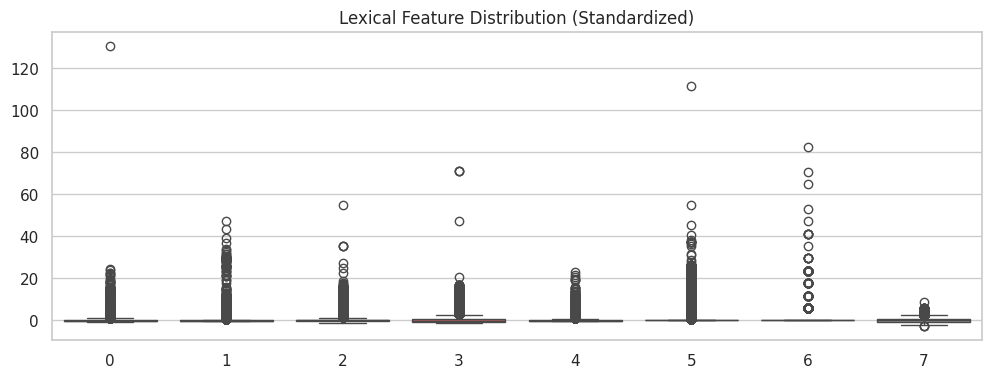


================ STEP 3: TF-IDF FEATURES ================
🔤 TF-IDF Feature Dimension: 50000
📦 Final ML Feature Size: 50008

================ STEP 4: ONLINE ML MODEL ================
🔍 Sample ML Probabilities: [8.31487043e-01 9.26847901e-01 3.90050681e-04 8.32311363e-01
 8.73515672e-01 9.87385375e-01 7.52429320e-01 7.46902492e-01
 1.83680926e-01 3.57804598e-02]
📈 ML AUC: 0.9797441810937499


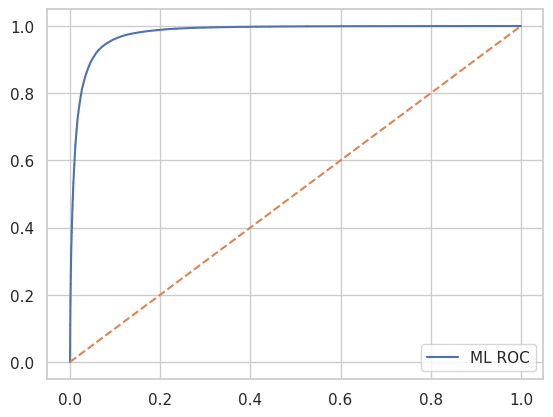


================ STEP 5: ISOLATION FOREST ================
🚨 Sample Anomaly Scores: [0.12846608 0.13590054 0.21483867 0.07726364 0.02652747 0.09022577
 0.07937169 0.11752363 0.05634229 0.0579931 ]


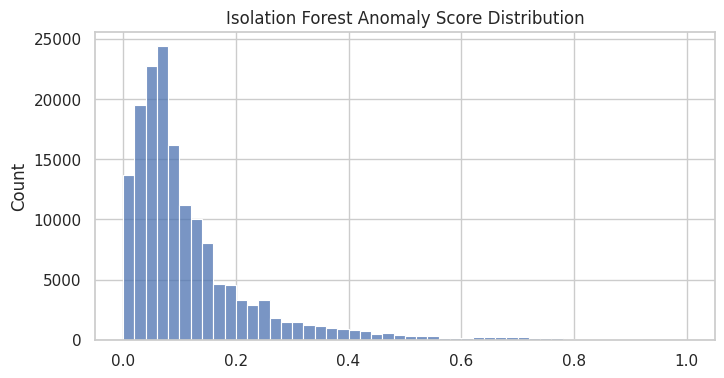


================ STEP 6: DEEP TCN + ATTENTION ================
Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
🔍 Sample DL Probabilities: [9.9309230e-01 9.8942918e-01 1.4754606e-05 9.9866700e-01 9.9067020e-01
 9.9846917e-01 9.6469635e-01 6.1842102e-01 5.0370296e-04 8.7215396e-04]
📈 DL AUC: 0.993154894140625


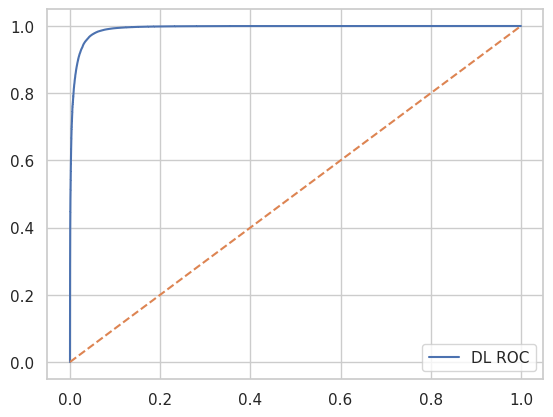


================ STEP 7–9: FUSION + META ================
⚖️ Meta Classifier Weights [ML, DL, Anomaly]:
[[ 3.51803071  6.26951829 -0.60155495]]
🎯 Best Threshold: 0.3125281597205237

📌 ML
Accuracy : 0.93150625
Precision: 0.9079231905465288
Recall   : 0.9604125
F1 Score : 0.9334305239179954
AUC      : 0.9797441810937499

📌 DL
Accuracy : 0.9592
Precision: 0.9672602391249046
Recall   : 0.950575
F1 Score : 0.9588450384566889
AUC      : 0.993154894140625

📌 HYBRID
Accuracy : 0.9623375
Precision: 0.9514794199501977
Recall   : 0.9743625
F1 Score : 0.962785010251723
AUC      : 0.992326781875

================ STEP 10: DRIFT DETECTION ================
🚨 Drift detected at index: 43772
🚨 Drift detected at index: 50269
🚨 Drift detected at index: 73807
🚨 Drift detected at index: 77639
🚨 Drift detected at index: 85601
🚨 Drift detected at index: 90359
🚨 Drift detected at index: 109803
🚨 Drift detected at index: 124252

📉 Total Drift Points: 8
📍 Drift Indices: [43772, 50269, 73807, 77639, 85601, 90359

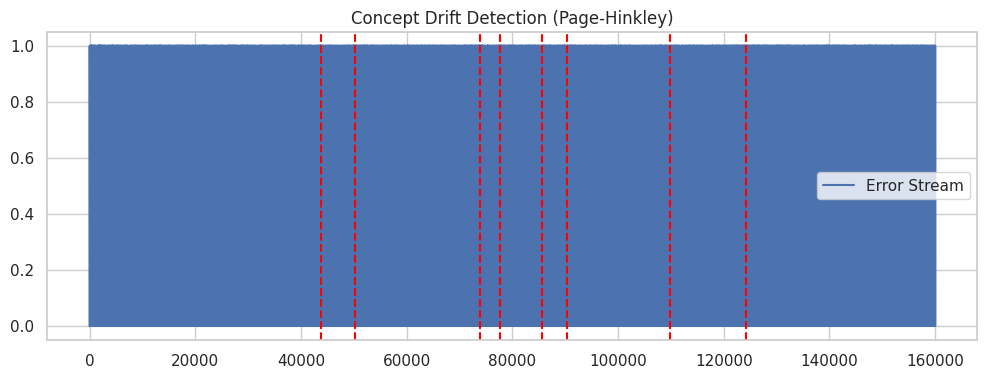


PIPELINE COMPLETED SUCCESSFULLY 🚀


In [1]:
# ==========================================================
# RESEARCH-GRADE HYBRID PHISHING URL DETECTION SYSTEM
# AUTO-TUNED + STACKED + DRIFT-AWARE
# FULL VISUAL + NUMERICAL EXPLANATION (FINAL)
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc
)
from scipy.sparse import hstack

sns.set(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

# ==========================================================
print("\n================ STEP 1: DATA LOADING ================")

BASE = "/content/drive/MyDrive/data"

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL":"url","label":"labels"})
    df = df[["url","labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    return df

train_df = load_data(os.path.join(BASE,"train.csv"))
test_df  = load_data(os.path.join(BASE,"test.csv"))
phi_df   = load_data(os.path.join(BASE,"phiusiil.csv"))

print("📊 Dataset Sizes")
print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("PHI  :", phi_df.shape)

print("\n📊 Train Class Distribution")
print(train_df.labels.value_counts(normalize=True))

# ==========================================================
print("\n================ STEP 2: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'), url.count('-'),
        url.count('%'), url.count('@'),
        math.log2(len(url)+1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

scaler_lex = StandardScaler()
X_lex_train = scaler_lex.fit_transform(X_lex_train)
X_lex_test  = scaler_lex.transform(X_lex_test)
X_lex_phi   = scaler_lex.transform(X_lex_phi)

print("📐 Lexical Feature Mean (Train):")
print(X_lex_train.mean(axis=0))

print("📐 Lexical Feature Std (Train):")
print(X_lex_train.std(axis=0))

plt.figure(figsize=(12,4))
sns.boxplot(data=pd.DataFrame(X_lex_train))
plt.title("Lexical Feature Distribution (Standardized)")
plt.show()

# ==========================================================
print("\n================ STEP 3: TF-IDF FEATURES ================")

tfidf = TfidfVectorizer(analyzer="char", ngram_range=(2,6), min_df=3, max_features=50000)
X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

print("🔤 TF-IDF Feature Dimension:", X_ng_train.shape[1])

X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_test_ml  = hstack([X_ng_test, X_lex_test]).tocsr()
X_phi_ml   = hstack([X_ng_phi, X_lex_phi]).tocsr()

print("📦 Final ML Feature Size:", X_train_ml.shape[1])

# ==========================================================
print("\n================ STEP 4: ONLINE ML MODEL ================")

clf = SGDClassifier(loss="log_loss", class_weight="balanced")
clf.fit(X_train_ml, train_df.labels)

p_ml_test = clf.predict_proba(X_test_ml)[:,1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:,1]

print("🔍 Sample ML Probabilities:", p_ml_test[:10])

fpr,tpr,_ = roc_curve(test_df.labels,p_ml_test)
print("📈 ML AUC:", auc(fpr,tpr))

plt.plot(fpr,tpr,label="ML ROC")
plt.plot([0,1],[0,1],'--')
plt.legend(); plt.show()

# ==========================================================
print("\n================ STEP 5: ISOLATION FOREST ================")

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_lex_train[train_df.labels==0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

scaler_anom = MinMaxScaler()
a_test = scaler_anom.fit_transform(a_test.reshape(-1,1)).flatten()
a_phi  = scaler_anom.transform(a_phi.reshape(-1,1)).flatten()

print("🚨 Sample Anomaly Scores:", a_test[:10])

plt.figure(figsize=(8,4))
sns.histplot(a_test, bins=50)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.show()

# ==========================================================
print("\n================ STEP 6: DEEP TCN + ATTENTION ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url.astype(str))))
char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"]=0

def encode(u):
    s=[char2idx.get(c,0) for c in str(u)[:MAX_LEN]]
    return s+[0]*(MAX_LEN-len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X=[encode(u) for u in urls]
        self.y=y.values
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i],dtype=torch.float)

train_dl=DataLoader(URLDS(train_df.url,train_df.labels),256,shuffle=True)
test_dl =DataLoader(URLDS(test_df.url,test_df.labels),256)

class DeepTCN(nn.Module):
    def __init__(self,v):
        super().__init__()
        self.emb=nn.Embedding(v,64,padding_idx=0)
        self.conv1=nn.Conv1d(64,128,3,padding=1)
        self.conv2=nn.Conv1d(128,128,3,padding=1)
        self.dropout=nn.Dropout(0.3)
        self.attn=nn.Linear(128,1)
        self.fc=nn.Linear(128,1)
    def forward(self,x):
        x=self.emb(x).transpose(1,2)
        x=torch.relu(self.conv1(x))
        x=torch.relu(self.conv2(x))
        x=self.dropout(x).transpose(1,2)
        w=torch.softmax(self.attn(x).squeeze(-1),1)
        return self.fc((x*w.unsqueeze(-1)).sum(1)).squeeze()

model=DeepTCN(len(char2idx)).to(device)
opt=torch.optim.Adam(model.parameters(),lr=0.001)
lossf=nn.BCEWithLogitsLoss()

for e in range(8):
    for X,y in train_dl:
        X,y=X.to(device),y.to(device)
        opt.zero_grad()
        loss=lossf(model(X),y)
        loss.backward()
        opt.step()
    print(f"Epoch {e+1} completed")

def dl_scores(dl):
    model.eval(); s=[]
    with torch.no_grad():
        for X,_ in dl:
            s.extend(torch.sigmoid(model(X.to(device))).cpu().numpy())
    return np.array(s)

p_dl_test = dl_scores(test_dl)
print("🔍 Sample DL Probabilities:", p_dl_test[:10])

fpr,tpr,_ = roc_curve(test_df.labels,p_dl_test)
print("📈 DL AUC:", auc(fpr,tpr))

plt.plot(fpr,tpr,label="DL ROC")
plt.plot([0,1],[0,1],'--')
plt.legend(); plt.show()

# ==========================================================
print("\n================ STEP 7–9: FUSION + META ================")

meta_X = np.column_stack([p_ml_test,p_dl_test,a_test])
meta_clf = SGDClassifier(loss="log_loss")
meta_clf.fit(meta_X,test_df.labels)

print("⚖️ Meta Classifier Weights [ML, DL, Anomaly]:")
print(meta_clf.coef_)

S_test = meta_clf.predict_proba(meta_X)[:,1]

prec,rec,thr = precision_recall_curve(test_df.labels,S_test)
f1 = 2*prec*rec/(prec+rec+1e-9)
best_thr = thr[np.argmax(f1)]

print("🎯 Best Threshold:", best_thr)

def print_metrics(y,yhat,s,name):
    print(f"\n📌 {name}")
    print("Accuracy :", accuracy_score(y,yhat))
    print("Precision:", precision_score(y,yhat))
    print("Recall   :", recall_score(y,yhat))
    print("F1 Score :", f1_score(y,yhat))
    fpr,tpr,_ = roc_curve(y,s)
    print("AUC      :", auc(fpr,tpr))

print_metrics(test_df.labels,(p_ml_test>0.5),p_ml_test,"ML")
print_metrics(test_df.labels,(p_dl_test>0.5),p_dl_test,"DL")
print_metrics(test_df.labels,(S_test>best_thr),S_test,"HYBRID")

# ==========================================================
print("\n================ STEP 10: DRIFT DETECTION ================")

class PageHinkley:
    def __init__(self,delta=0.002,lam=15):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.mean=0; self.sum=0; self.min=0; self.t=0
    def update(self,x):
        self.t+=1
        self.mean+=(x-self.mean)/self.t
        self.sum+=x-self.mean-self.delta
        self.min=min(self.min,self.sum)
        if self.sum-self.min>self.lam:
            self.reset(); return True
        return False

ph=PageHinkley()
losses=[]; drifts=[]

for i in range(len(test_df)):
    err=int((S_test[i]>best_thr)!=test_df.labels.iloc[i])
    losses.append(err)
    if ph.update(err):
        drifts.append(i)
        print("🚨 Drift detected at index:", i)

print("\n📉 Total Drift Points:", len(drifts))
print("📍 Drift Indices:", drifts)
print("📊 Drift Rate:", len(drifts)/len(test_df))

plt.figure(figsize=(12,4))
plt.plot(losses,label="Error Stream")
for d in drifts:
    plt.axvline(d,color="red",ls="--")
plt.legend()
plt.title("Concept Drift Detection (Page-Hinkley)")
plt.show()

print("\nPIPELINE COMPLETED SUCCESSFULLY 🚀")
